# MJ Barros Visualization (Notebook)

Notebook para carregar o CSV consolidado da MJ Barros, filtrar apenas \"Casa\" e \"Casa de Condominio\" e gerar grafico de dispersao com escala log-log (preco vs area), usando cor para separar categorias.

In [89]:
from pathlib import Path
import unicodedata

import pandas as pd

try:
    from plotnine import (
        ggplot, aes, geom_point, scale_x_log10, scale_y_log10, labs, theme_bw
    )
except Exception as exc:
    raise ImportError(
        "Pacote 'plotnine' nao encontrado. Instale com: pip install plotnine"
    ) from exc

In [90]:
# Configuracao
CSV_DIR = Path('../data/processed/csv')
CSV_PATTERN = 'mjbarros_*.csv'

def find_latest_csv(csv_dir: Path = CSV_DIR, pattern: str = CSV_PATTERN) -> Path:
    files = sorted(csv_dir.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f'Nenhum CSV encontrado em: {csv_dir.resolve()}')
    return files[-1]

def load_csv(csv_file: Path) -> pd.DataFrame:
    if not csv_file.exists():
        raise FileNotFoundError(f'Arquivo CSV nao encontrado: {csv_file}')
    return pd.read_csv(csv_file, sep=';')

def normalize_text(value: str | None) -> str:
    if value is None:
        return ''
    text = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode('ascii')
    return text.strip().lower()

def classify_categoria(tipo: str | None) -> str | None:
    norm = normalize_text(tipo)
    if norm == 'casa':
        return 'Casa'
    if norm == 'casa de condominio':
        return 'Casa de Condominio'
    return None

In [91]:
# Se quiser forcar um arquivo especifico, descomente e ajuste:
# csv_file = Path('../data/processed/csv/mjbarros_venda_2026-05-15.csv')

csv_file = find_latest_csv()
df = load_csv(csv_file)

print(f'CSV selecionado: {csv_file.resolve()}')
print(f'Linhas no CSV: {len(df)}')
df[['tipo', 'preco', 'area_m2']].head()

CSV selecionado: /home/marco/mba_genai/DSLLM/aula02/lessons/04_imoveis_selenium/data/processed/csv/mjbarros_venda_2026-05-24.csv
Linhas no CSV: 434


,tipo,preco,area_m2
0,Terreno,350000.0,300.0
1,Casa de Condomínio,1690000.0,170.0
2,Apartamento,1480000.0,118.0
3,Casa,620000.0,123.0
4,Terreno,165900.0,200.0


In [92]:
# Filtro: apenas Casa e Casa de Condominio
plot_df = df.copy()
plot_df['categoria'] = plot_df['tipo'].apply(classify_categoria)
plot_df = plot_df[plot_df['categoria'].notna()].copy()

# Remocao de valores invalidos para escala log
plot_df = plot_df[(plot_df['preco'].notna()) & (plot_df['area_m2'].notna())]
plot_df = plot_df[(plot_df['preco'] > 0) & (plot_df['area_m2'] > 0)]

print(f'Linhas para plot: {len(plot_df)}')
print(plot_df['categoria'].value_counts(dropna=False))
plot_df[['tipo', 'categoria', 'preco', 'area_m2']].head()

Linhas para plot: 166
categoria
Casa                  116
Casa de Condominio     50
Name: count, dtype: int64


,tipo,categoria,preco,area_m2
1,Casa de Condomínio,Casa de Condominio,1690000.0,170.0
3,Casa,Casa,620000.0,123.0
10,Casa,Casa,3390000.0,527.0
15,Casa,Casa,850000.0,134.0
16,Casa,Casa,550000.0,97.0


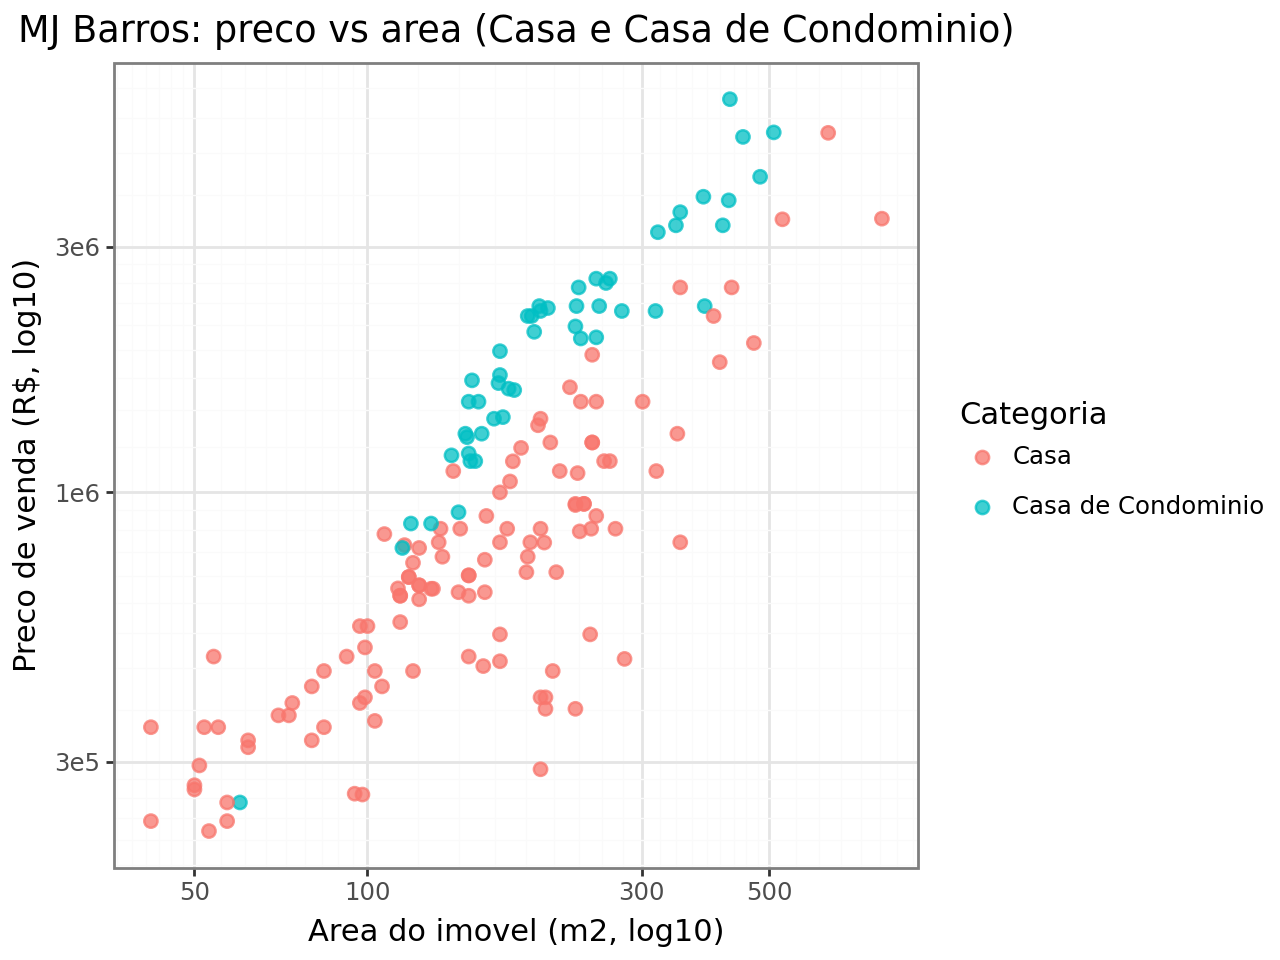

In [93]:
if plot_df.empty:
    raise RuntimeError('Nao ha dados de Casa/Casa de Condominio com preco e area positivos para gerar o grafico.')

plot_obj = (
    ggplot(plot_df, aes(x='area_m2', y='preco', color='categoria'))
    + geom_point(alpha=0.75, size=2.2)
    + scale_x_log10()
    + scale_y_log10()
    + labs(
        title='MJ Barros: preco vs area (Casa e Casa de Condominio)',
        x='Area do imovel (m2, log10)',
        y='Preco de venda (R$, log10)',
        color='Categoria'
    )
    + theme_bw()
)

plot_obj

## Distribuicao do preco de casas residenciais

Graficos para examinar a distribuicao dos precos apenas de casas residenciais: Casa, Casa de Condomínio e Sobrado.

In [94]:
from plotnine import (
    coord_flip,
    element_text,
    geom_boxplot,
    geom_density,
    geom_histogram,
    labs,
    scale_x_log10,
    scale_y_continuous,
    scale_y_log10,
    stat_ecdf,
    theme,
    theme_minimal,
)

tipos_casa_residencial = ['Casa', 'Casa de Condomínio', 'Sobrado']

tb_precos = (
    df
    .assign(preco=lambda dados: pd.to_numeric(dados['preco'], errors='coerce'))
    .query('tipo in @tipos_casa_residencial')
    .dropna(subset=['preco'])
    .query('preco > 0')
    .copy()
)

limite_p95 = tb_precos['preco'].quantile(0.95)
tb_precos_p95 = tb_precos.query('preco <= @limite_p95').copy()

print(f'Tipos incluidos: {", ".join(tipos_casa_residencial)}')
print(f'Casas residenciais com preco valido: {len(tb_precos)}')
print(f'Limite do percentil 95: R$ {limite_p95:,.0f}')
print(f'Casas residenciais ate o percentil 95: {len(tb_precos_p95)}')
tb_precos['preco'].describe()

Tipos incluidos: Casa, Casa de Condomínio, Sobrado
Casas residenciais com preco valido: 172
Limite do percentil 95: R$ 3,394,500
Casas residenciais ate o percentil 95: 163


count    1.720000e+02
mean     1.253988e+06
std      1.033829e+06
min      2.200000e+05
25%      5.337500e+05
50%      8.700000e+05
75%      1.607500e+06
max      5.800000e+06
Name: preco, dtype: float64

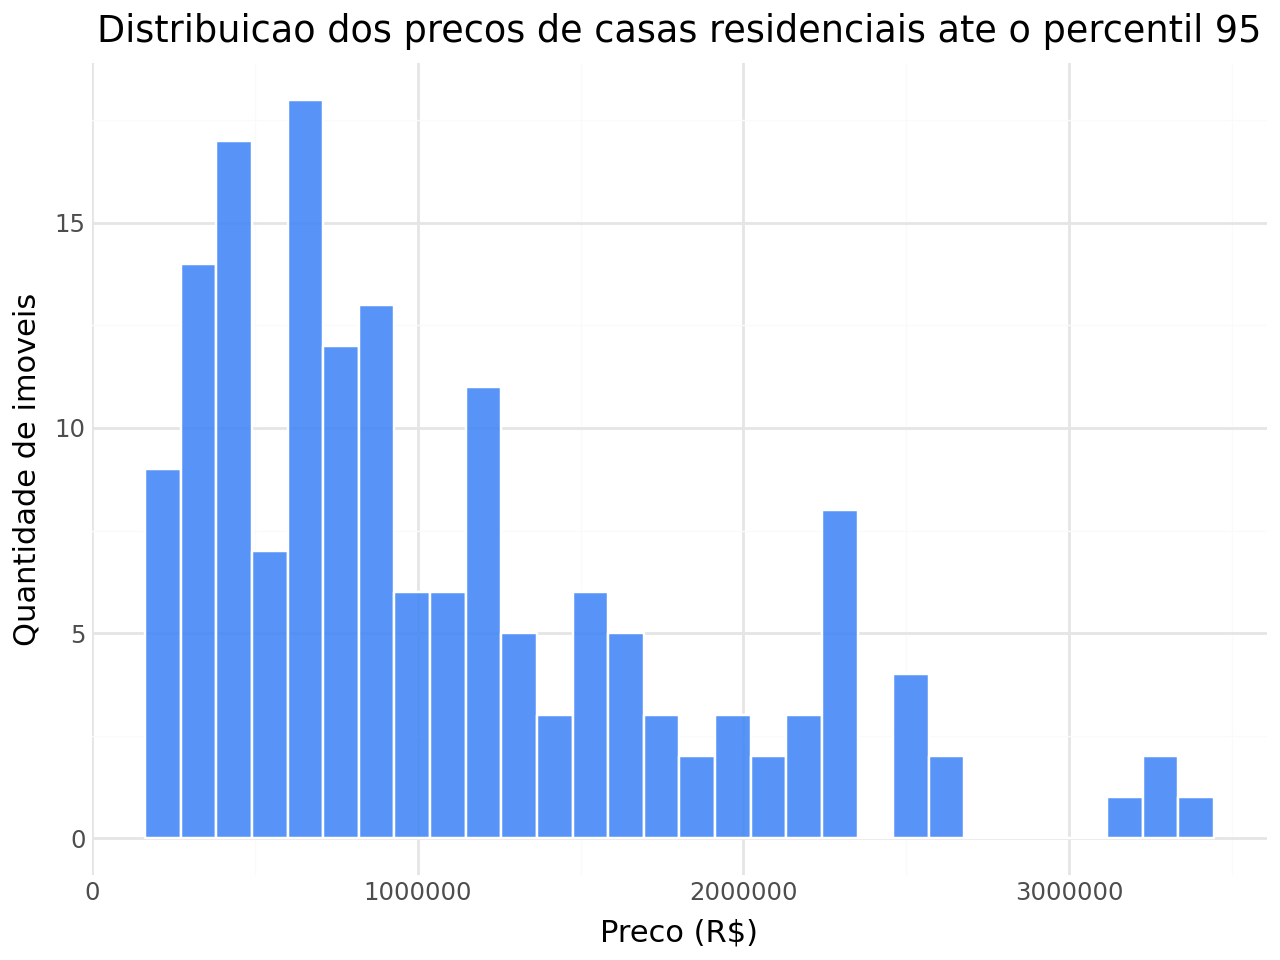

In [95]:
(
    ggplot(tb_precos_p95, aes(x='preco'))
    + geom_histogram(bins=30, fill='#3b82f6', color='white', alpha=0.85)
    + labs(
        title='Distribuicao dos precos de casas residenciais ate o percentil 95',
        x='Preco (R$)',
        y='Quantidade de imoveis',
    )
    + theme_minimal()
)

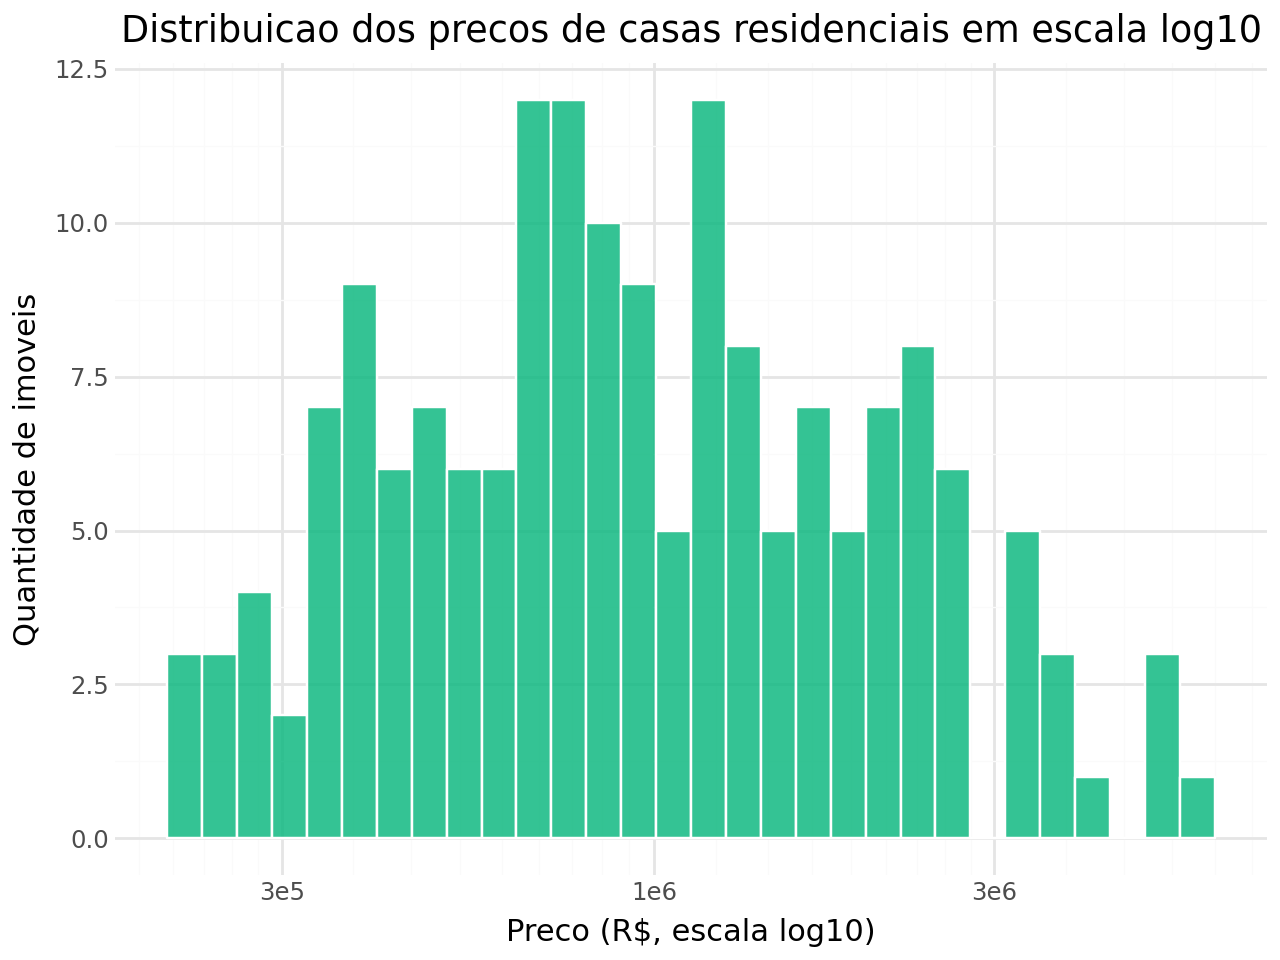

In [96]:
(
    ggplot(tb_precos, aes(x='preco'))
    + geom_histogram(bins=30, fill='#10b981', color='white', alpha=0.85)
    + scale_x_log10()
    + labs(
        title='Distribuicao dos precos de casas residenciais em escala log10',
        x='Preco (R$, escala log10)',
        y='Quantidade de imoveis',
    )
    + theme_minimal()
)

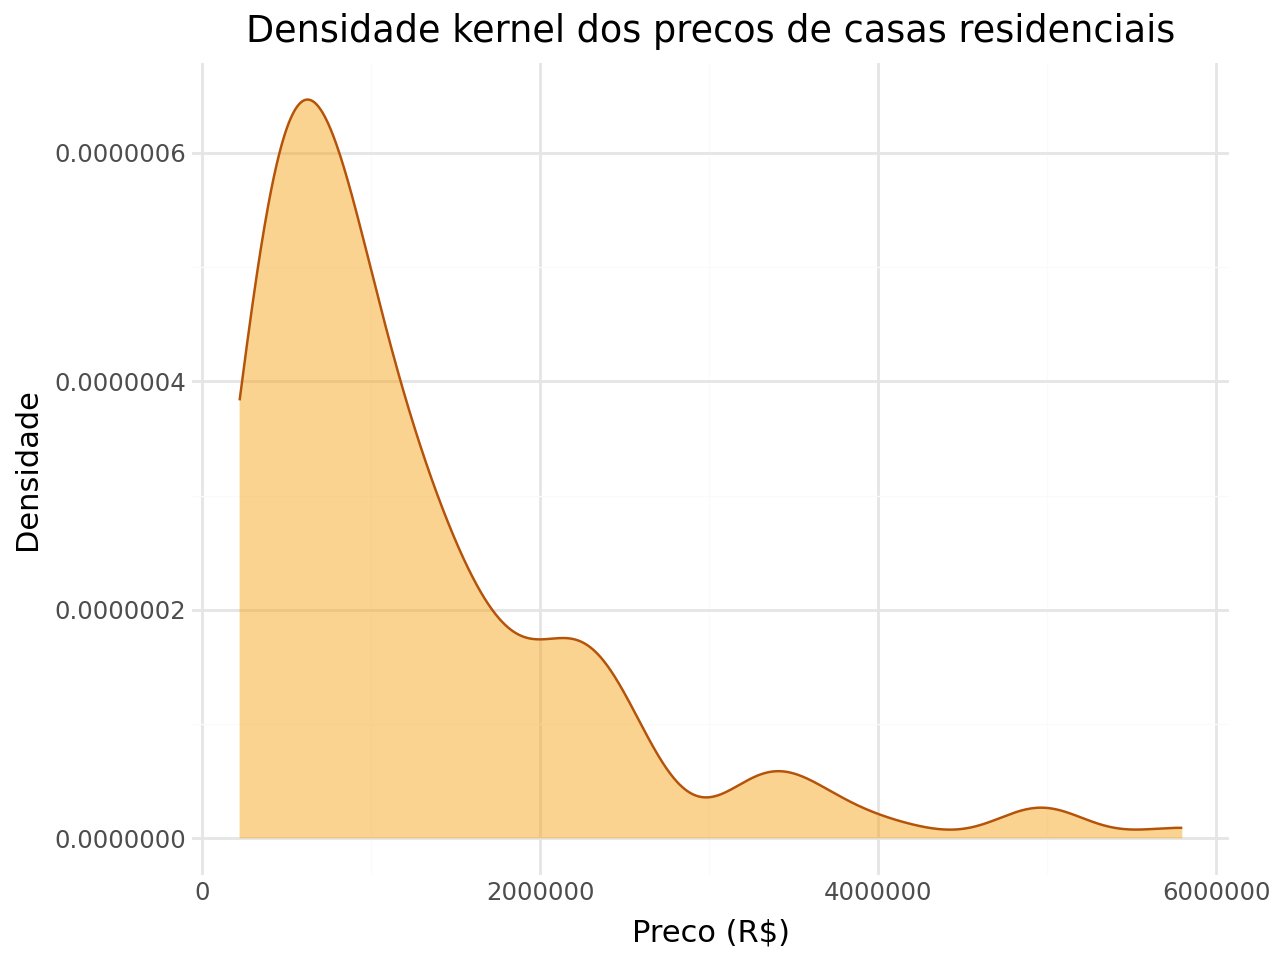

In [97]:
(
    ggplot(tb_precos, aes(x='preco'))
    + geom_density(fill='#f59e0b', color='#b45309', alpha=0.45)
    + labs(
        title='Densidade kernel dos precos de casas residenciais',
        x='Preco (R$)',
        y='Densidade',
    )
    + theme_minimal()
)

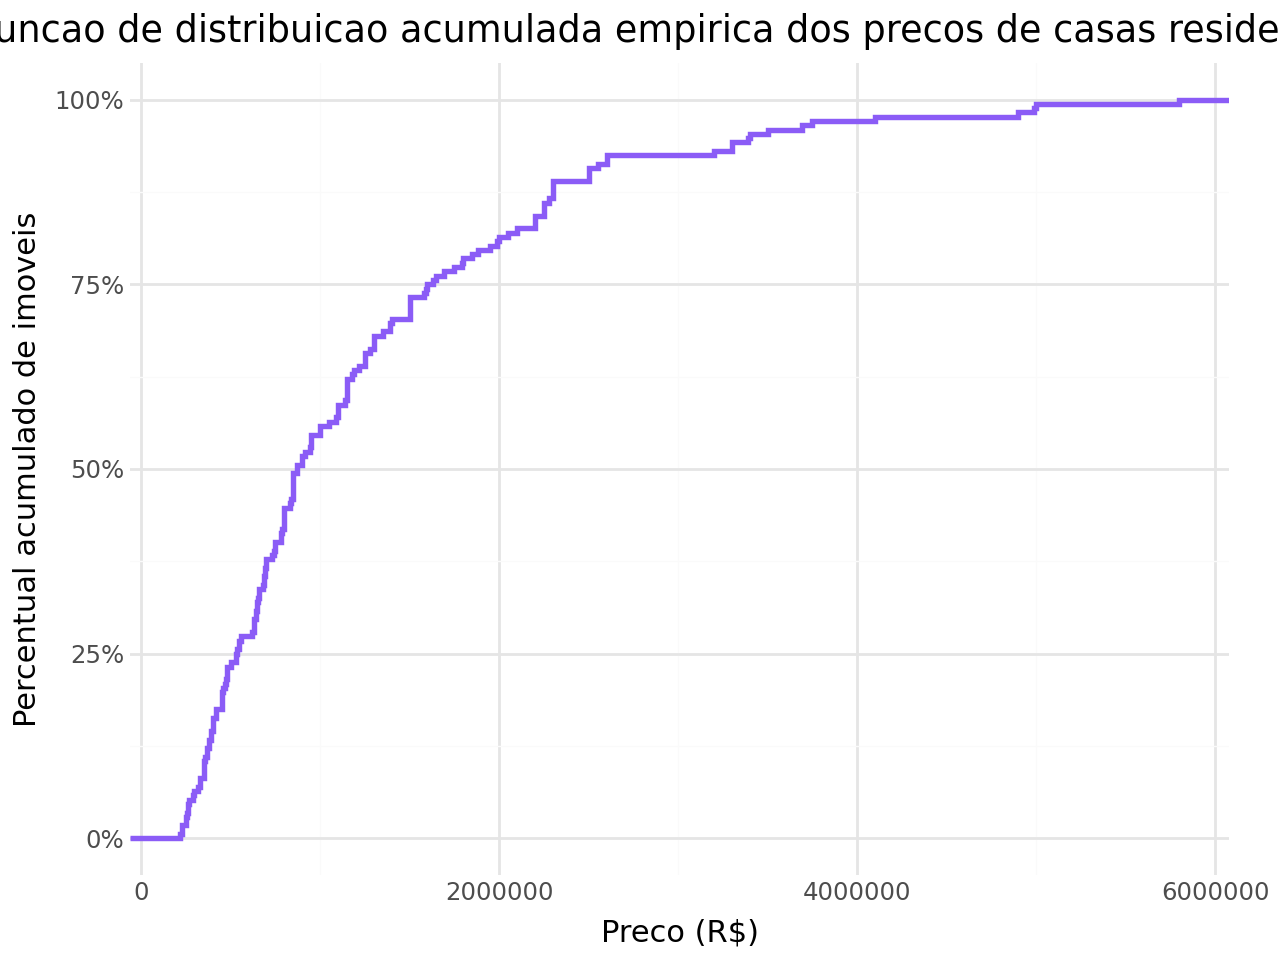

In [98]:
(
    ggplot(tb_precos, aes(x='preco'))
    + stat_ecdf(geom='step', color='#8b5cf6', size=1.1)
    + scale_y_continuous(labels=lambda values: [f'{value:.0%}' for value in values])
    + labs(
        title='Funcao de distribuicao acumulada empirica dos precos de casas residenciais',
        x='Preco (R$)',
        y='Percentual acumulado de imoveis',
    )
    + theme_minimal()
)

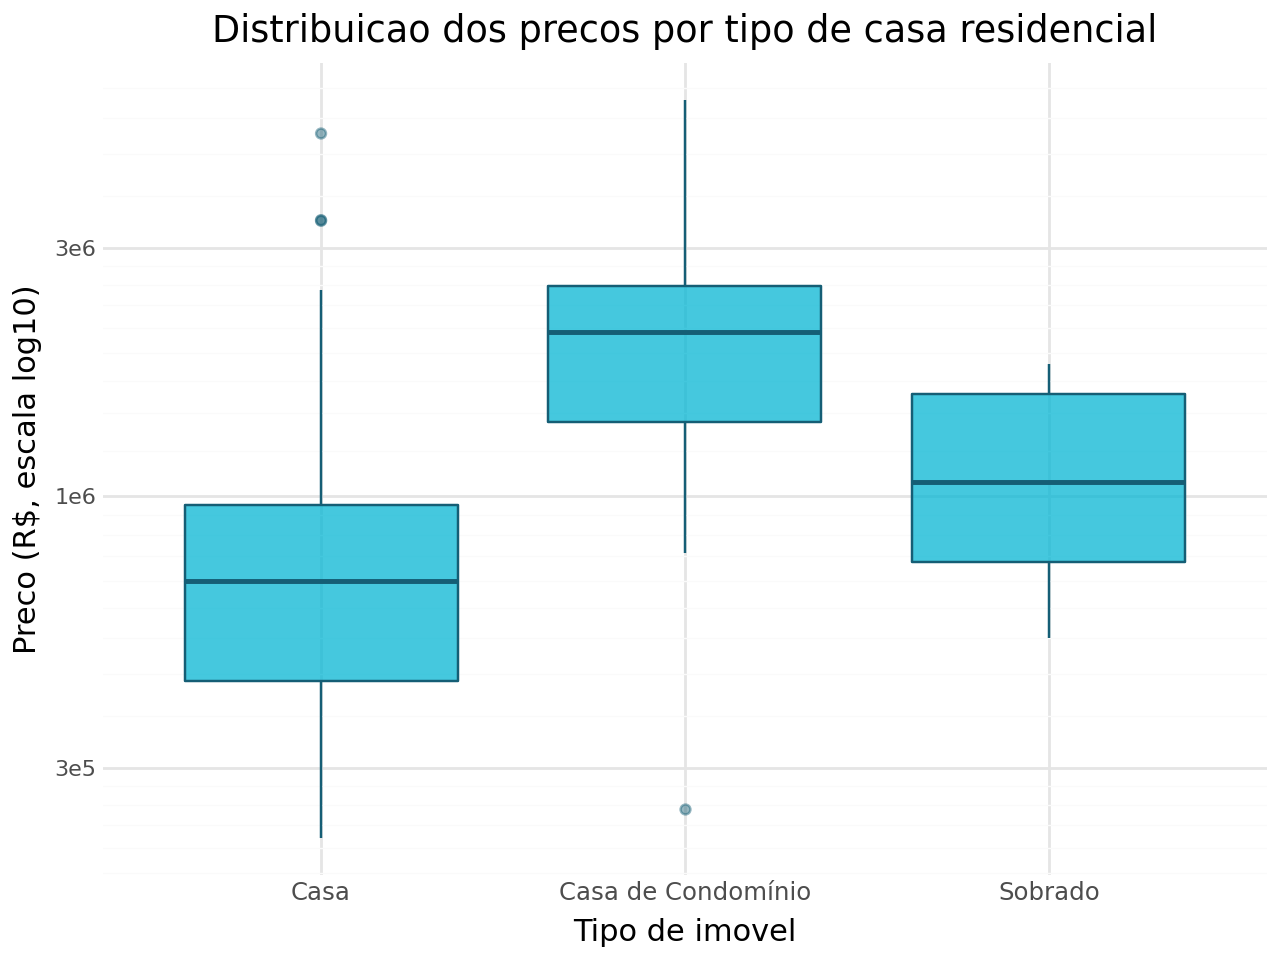

In [99]:
(
    ggplot(tb_precos.dropna(subset=['tipo']), aes(x='tipo', y='preco'))
    + geom_boxplot(fill='#06b6d4', color='#155e75', alpha=0.75, outlier_alpha=0.45)
    + scale_y_log10()
    + labs(
        title='Distribuicao dos precos por tipo de casa residencial',
        x='Tipo de imovel',
        y='Preco (R$, escala log10)',
    )
    + theme_minimal()
    + theme(axis_text_y=element_text(size=8))
)

## Frequencias e proporcoes das casas residenciais

Graficos de frequencia para quartos, suites e banheiros; proporcao por categoria residencial; e frequencia por bairro.

In [100]:
from plotnine import aes, coord_flip, facet_wrap, geom_col, ggplot, labs, theme_minimal
import matplotlib.pyplot as plt

categorias_residenciais = ['Casa', 'Casa de Condomínio', 'Sobrado']

tb_casas = (
    df
    .query('tipo in @categorias_residenciais')
    .copy()
)

for coluna in ['quartos', 'suites', 'banheiros']:
    if coluna in tb_casas.columns:
        tb_casas[coluna] = pd.to_numeric(tb_casas[coluna], errors='coerce')
    else:
        print(f"Coluna ausente no CSV: {coluna}. O grafico correspondente nao sera gerado.")

print(f'Casas residenciais consideradas: {len(tb_casas)}')
tb_casas['tipo'].value_counts()

Coluna ausente no CSV: suites. O grafico correspondente nao sera gerado.
Casas residenciais consideradas: 174


tipo
Casa                  117
Casa de Condomínio     51
Sobrado                 6
Name: count, dtype: int64

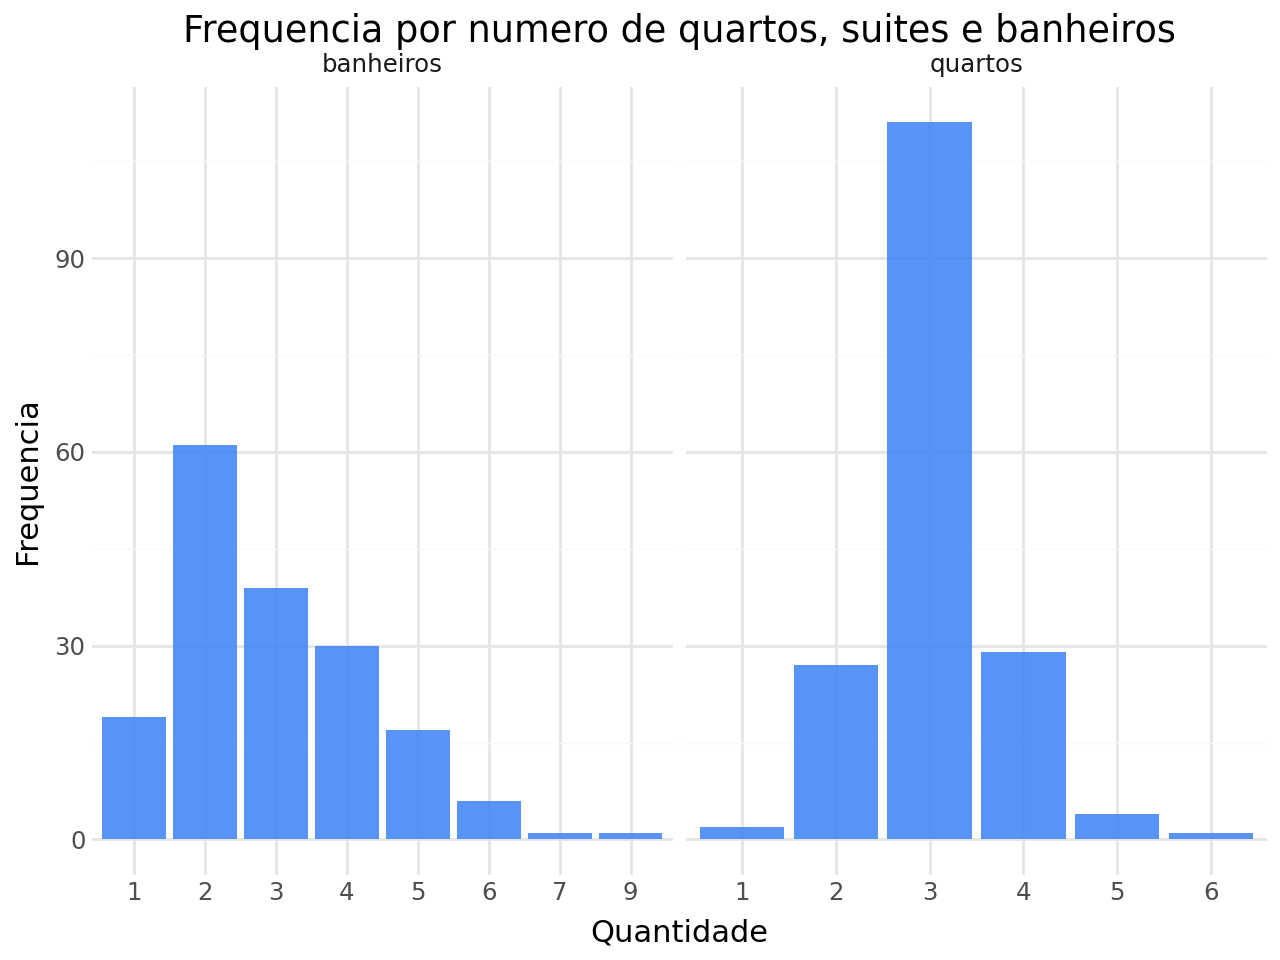

In [101]:
colunas_comodos = [coluna for coluna in ['quartos', 'suites', 'banheiros'] if coluna in tb_casas.columns]

freq_comodos = (
    tb_casas[colunas_comodos]
    .melt(var_name='caracteristica', value_name='quantidade')
    .dropna(subset=['quantidade'])
    .assign(quantidade=lambda dados: dados['quantidade'].astype(int))
    .groupby(['caracteristica', 'quantidade'], as_index=False)
    .size()
    .rename(columns={'size': 'frequencia'})
)

(
    ggplot(freq_comodos, aes(x='factor(quantidade)', y='frequencia'))
    + geom_col(fill='#3b82f6', alpha=0.85)
    + facet_wrap('~caracteristica', scales='free_x')
    + labs(
        title='Frequencia por numero de quartos, suites e banheiros',
        x='Quantidade',
        y='Frequencia',
    )
    + theme_minimal()
)

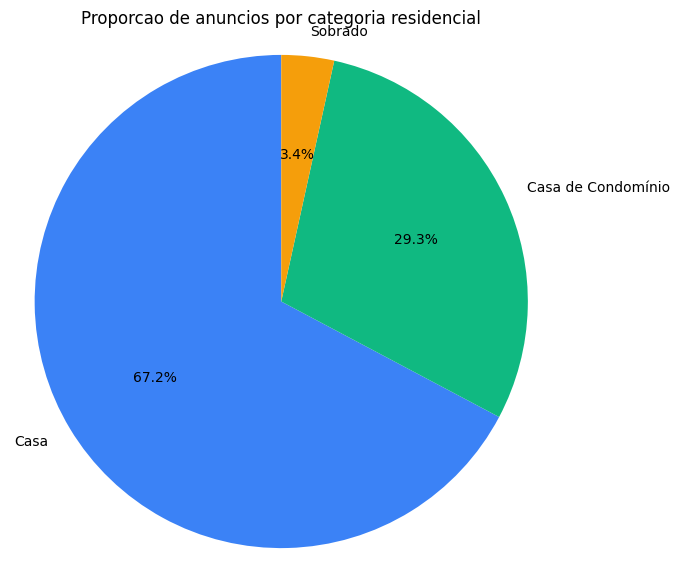

In [102]:
prop_tipo = tb_casas['tipo'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    prop_tipo.values,
    labels=prop_tipo.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#3b82f6', '#10b981', '#f59e0b'],
)
ax.set_title('Proporcao de anuncios por categoria residencial')
ax.axis('equal')
plt.show()

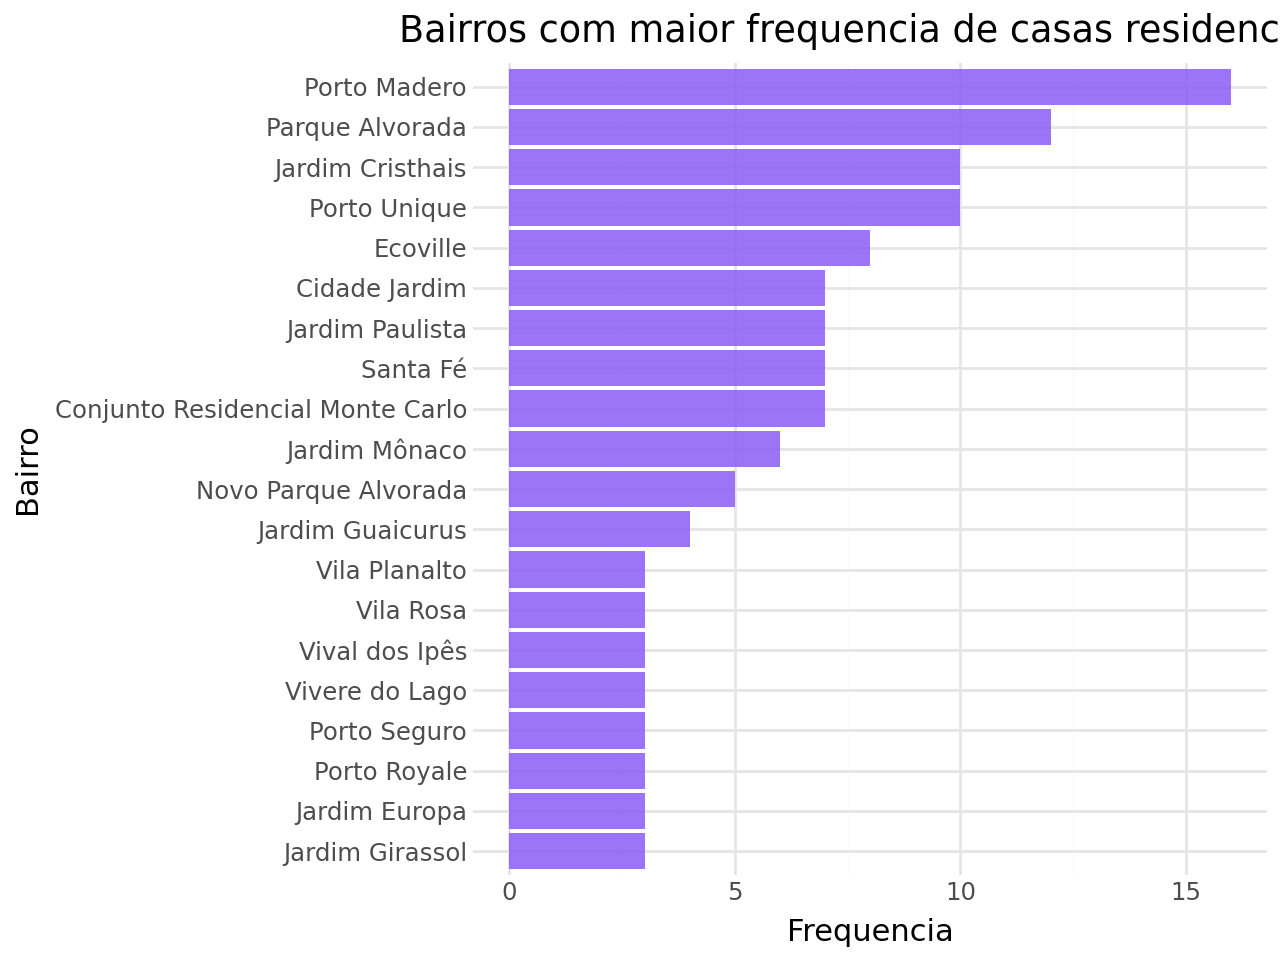

In [103]:
freq_bairros = (
    tb_casas
    .dropna(subset=['bairro'])
    .groupby('bairro', as_index=False)
    .size()
    .rename(columns={'size': 'frequencia'})
    .sort_values('frequencia', ascending=False)
    .head(20)
)

(
    ggplot(freq_bairros, aes(x='reorder(bairro, frequencia)', y='frequencia'))
    + geom_col(fill='#8b5cf6', alpha=0.85)
    + coord_flip()
    + labs(
        title='Bairros com maior frequencia de casas residenciais',
        x='Bairro',
        y='Frequencia',
    )
    + theme_minimal()
)

## Relacao entre preco, area, tipo e bairro

Graficos bivariados para examinar a relacao do preco e da area dos imoveis com tipo e bairro.

In [104]:
from plotnine import element_text, geom_boxplot, geom_point, scale_color_brewer, scale_x_continuous, theme

def format_brl_curto(values):
    labels = []
    for value in values:
        if value >= 1_000_000:
            labels.append(f'R$ {value / 1_000_000:.1f} mi')
        elif value >= 1_000:
            labels.append(f'R$ {value / 1_000:.0f} mil')
        else:
            labels.append(f'R$ {value:.0f}')
    return labels


def format_m2(values):
    return [f'{value:.0f} m²' for value in values]


tb_bivariada = (
    tb_casas
    .assign(
        preco=lambda dados: pd.to_numeric(dados['preco'], errors='coerce'),
        area_m2=lambda dados: pd.to_numeric(dados['area_m2'], errors='coerce'),
    )
    .dropna(subset=['preco', 'area_m2', 'tipo', 'bairro'])
    .query('preco > 0 and area_m2 > 0')
    .copy()
)

bairros_top = tb_bivariada['bairro'].value_counts().head(10).index
tb_bivariada_top_bairros = tb_bivariada.query('bairro in @bairros_top').copy()

print(f'Casas residenciais com preco e area validos: {len(tb_bivariada)}')
print(f'Bairros no facetamento: {len(bairros_top)}')
tb_bivariada[['preco', 'area_m2']].describe()

Casas residenciais com preco e area validos: 172
Bairros no facetamento: 10


,preco,area_m2
count,1.720000e+02,172.000000
mean,1.253988e+06,197.226744
std,1.033829e+06,115.948420
min,2.200000e+05,42.000000
25%,5.337500e+05,119.750000
50%,8.700000e+05,170.000000
75%,1.607500e+06,239.500000
max,5.800000e+06,785.000000


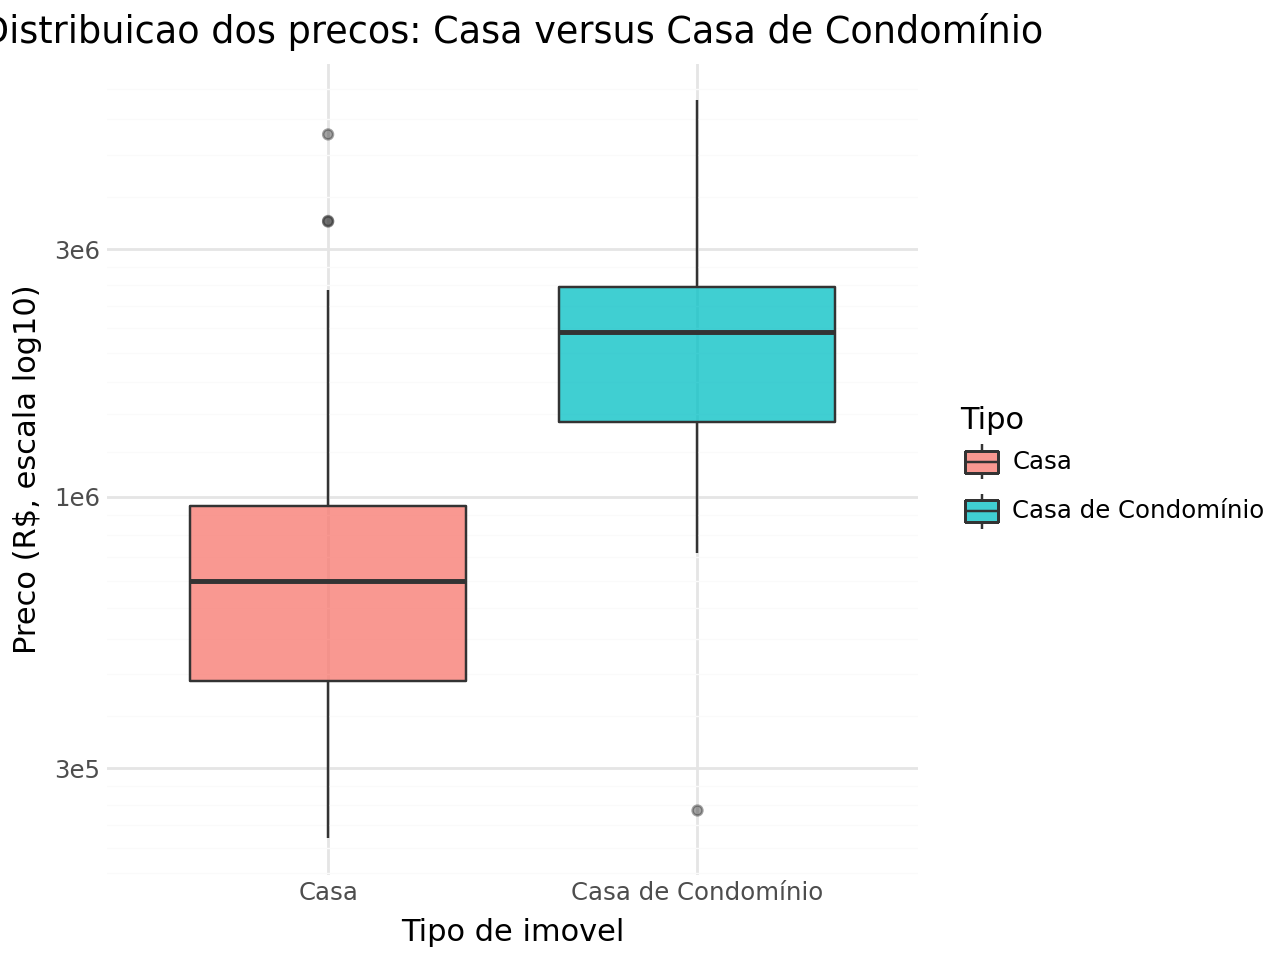

In [105]:
tb_casa_vs_condominio = tb_bivariada.query("tipo in ['Casa', 'Casa de Condomínio']").copy()

(
    ggplot(tb_casa_vs_condominio, aes(x='tipo', y='preco', fill='tipo'))
    + geom_boxplot(alpha=0.75, outlier_alpha=0.45)
    + scale_y_log10()
    + labs(
        title='Distribuicao dos precos: Casa versus Casa de Condomínio',
        x='Tipo de imovel',
        y='Preco (R$, escala log10)',
        fill='Tipo',
    )
    + theme_minimal()
)

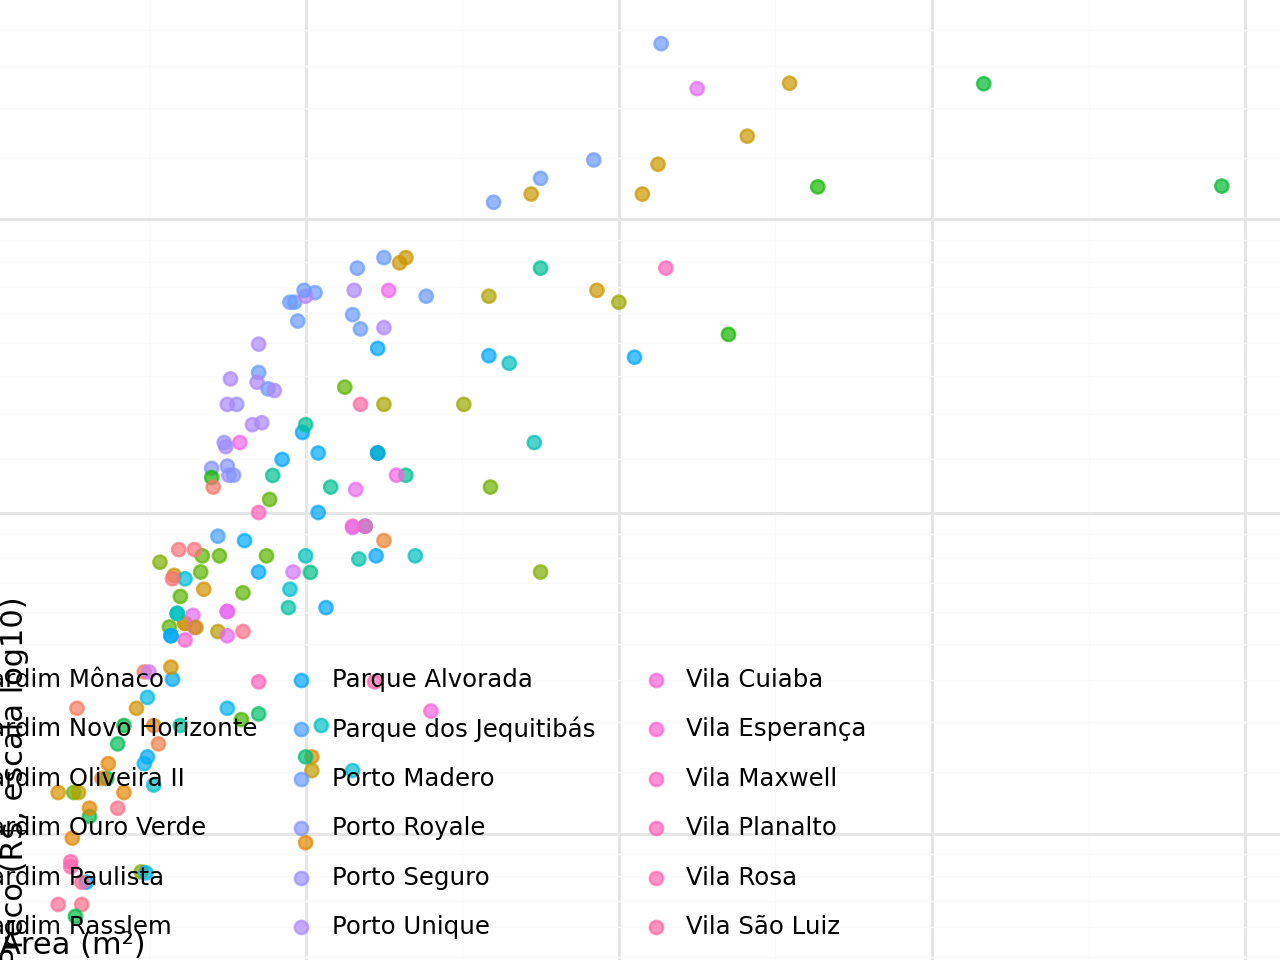

In [106]:
(
    ggplot(tb_bivariada, aes(x='area_m2', y='preco', color='bairro'))
    + geom_point(alpha=0.72, size=2.4)
    + scale_x_continuous(labels=format_m2)
    + scale_y_log10(labels=format_brl_curto)
    + labs(
        title='Preco versus area das casas residenciais por bairro',
        x='Area construida (m²)',
        y='Preco de venda (R$)',
        color='Bairro',
    )
    + theme_minimal()
    + theme(
        legend_position='right',
        axis_text_x=element_text(rotation=35, ha='right'),
    )
)

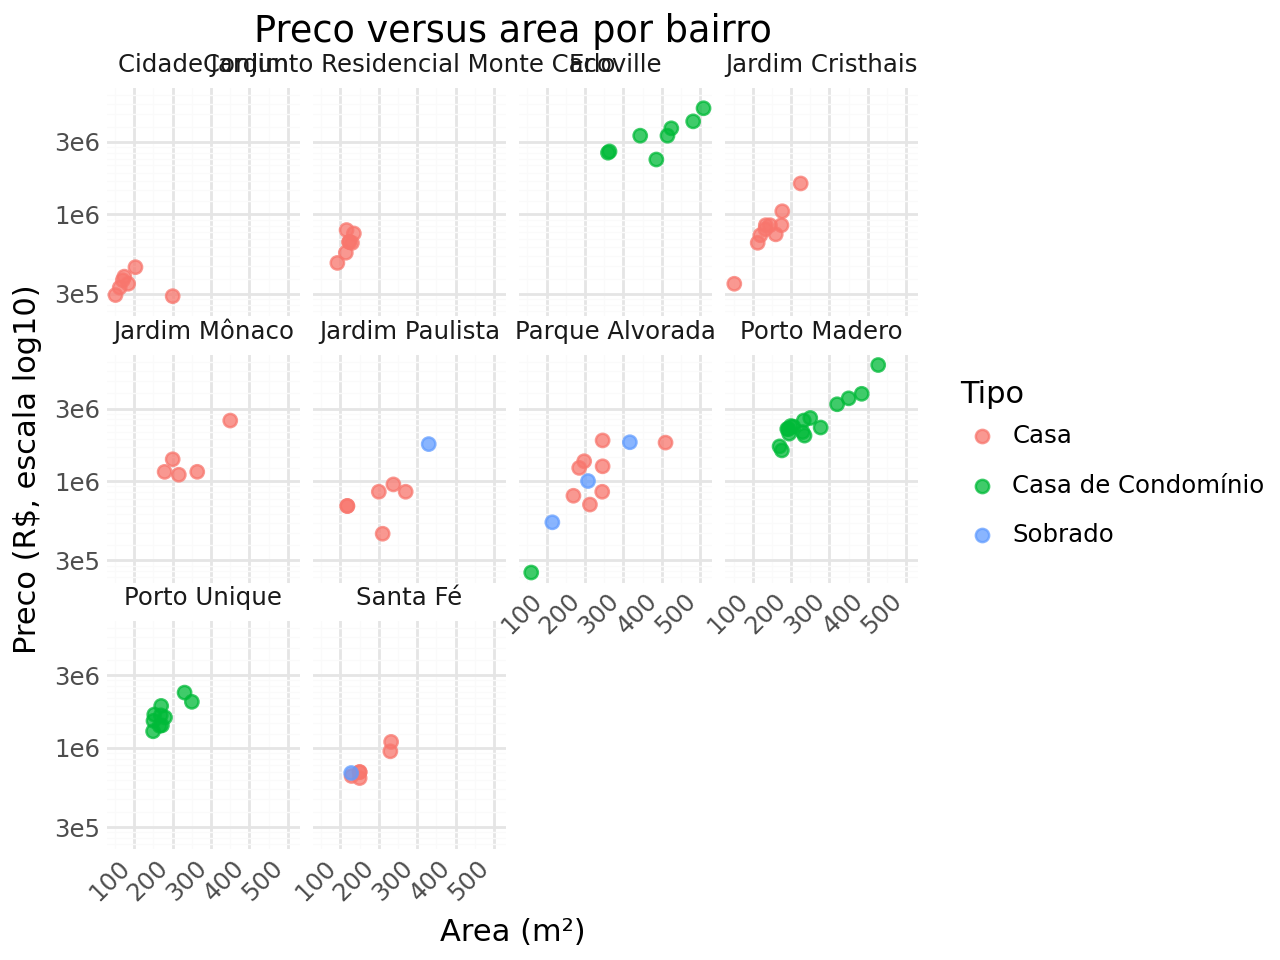

In [107]:
(
    ggplot(tb_bivariada_top_bairros, aes(x='area_m2', y='preco', color='tipo'))
    + geom_point(alpha=0.78, size=2.3)
    + scale_x_continuous(labels=format_m2)
    + scale_y_log10(labels=format_brl_curto)
    + facet_wrap('~bairro', scales='free_x')
    + labs(
        title='Preco versus area por bairro',
        x='Area construida (m²)',
        y='Preco de venda (R$)',
        color='Tipo',
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45, ha='right'),
        subplots_adjust={'wspace': 0.25, 'hspace': 0.35},
    )
)